# BDTs to separate the signal from double charm backgrounds

### Setting up the data and tools

In [1]:
# Importing the notebook with common setup 
%run 'setup_mc.ipynb'

Welcome to JupyROOT 6.28/00


Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903000") to load datasets
Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903003") to load dataset for double charm
Invoke  df_signal_23903000 = load_signal_from_inclMC() to load signal from 23903000 Inclusive MC
or
Invoke  df_signal = load_signal_all()
Invoke  df_background = load_background_category(category)


### Loading the dataframe with signal and all types of backgrounds

In [2]:
%%time
dfall = load_complete_df()

CPU times: user 13.8 s, sys: 494 ms, total: 14.3 s
Wall time: 25.7 s


In [3]:
df = dfall.query('eventIndex == 0')

In [4]:
mygroupby(df, 'signal')

,signal,count,Percentage,cumulative %
0,0,318712,98.070361,98.070361
1,1,6271,1.929639,100.000000


In [5]:
mygroupby(dfall.query("eventIndex == 1"), 'signal')

,signal,count,Percentage,cumulative %
0,0,318559,98.073679,98.073679
1,1,6257,1.926321,100.000000


In [6]:
import xgboost as xgb
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.utils import shuffle

# Classifier to separate signal to all other backgrounds

### Data Preparation

In [7]:
mygroupby(df, 'signal')

,signal,count,Percentage,cumulative %
0,0,318712,98.070361,98.070361
1,1,6271,1.929639,100.000000


### Columns of interest

In [8]:
train_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
    "log(abs(PBsn))",
    "log(abs(PBv/B_P))",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "mN2v",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]

### Split the dataset in training and test sets

In [9]:
from sklearn.model_selection import train_test_split
df = shuffle(df)
train, test = train_test_split(df, test_size=0.2)

In [10]:
Xtrain = train[train_columns]
ytrain = train["signal"]
Xtest = test[train_columns]
ytest = test["signal"]

In [11]:
Xtrain.shape

(259986, 23)

### Scaling the features for easier training

In [12]:
%%time
from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit(Xtrain)
Xtrain_scaled = scaler.transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)

CPU times: user 92.3 ms, sys: 36.7 ms, total: 129 ms
Wall time: 125 ms


In [13]:
type(Xtest)

pandas.core.frame.DataFrame

In [14]:
type(Xtest_scaled)

numpy.ndarray

In [15]:
#plt.hist(Xtest_scaled[:,5], bins=200, range=[-3,3]);

In [16]:
#pd.DataFrame(Xtrain_scaled, columns=Xtrain.columns).describe()

### Training an XGBoost classifier

In [17]:
ratio = len(train[train['signal']==0]) / len(train[train['signal']==1])
print(ratio)

50.6768038163387


In [18]:
model = xgb.XGBClassifier( eval_metric='logloss', 
                          n_estimators=200, eta=0.03, scale_pos_weight=ratio, max_depth=4, random_state=42, train_method="hist_gpu")
xgbclass = make_pipeline(scaler, model)
model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.03, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, predictor=None, ...)

In [ ]:
%%time
evalset = [(Xtrain_scaled, ytrain), (Xtest_scaled, ytest)]
res = model.fit(Xtrain_scaled, ytrain, eval_set=evalset)

[17:47:55] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1679035063795/work/src/learner.cc:767: 
Parameters: { "train_method" } are not used.

[0]	validation_0-logloss:0.68436	validation_1-logloss:0.68442
[1]	validation_0-logloss:0.67612	validation_1-logloss:0.67625
[2]	validation_0-logloss:0.66837	validation_1-logloss:0.66857
[3]	validation_0-logloss:0.66106	validation_1-logloss:0.66132
[4]	validation_0-logloss:0.65416	validation_1-logloss:0.65451
[5]	validation_0-logloss:0.64754	validation_1-logloss:0.64793
[6]	validation_0-logloss:0.64135	validation_1-logloss:0.64182
[7]	validation_0-logloss:0.63533	validation_1-logloss:0.63589
[8]	validation_0-logloss:0.62977	validation_1-logloss:0.63035
[9]	validation_0-logloss:0.62425	validation_1-logloss:0.62494
[10]	validation_0-logloss:0.61912	validation_1-logloss:0.61990
[11]	validation_0-logloss:0.61418	validation_1-logloss:0.61502
[12]	validation_0-logloss:0.60921	validation_1-logloss:0.61014
[13]	validation_0-logloss:0.

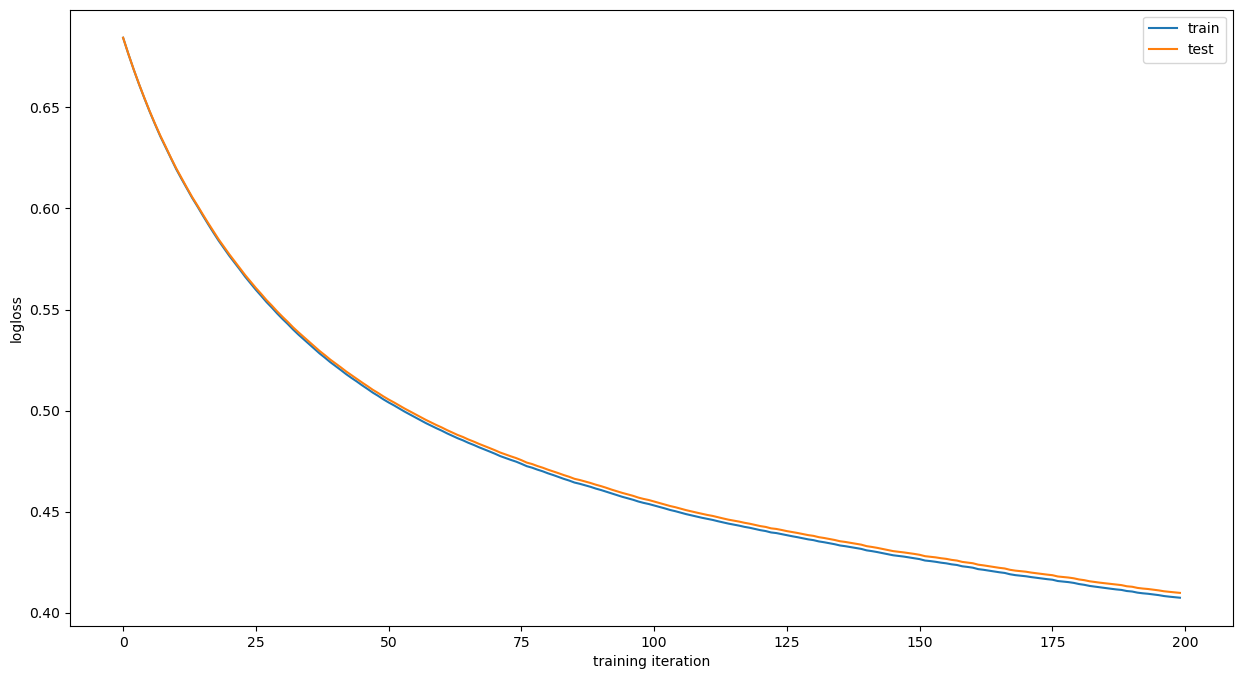

In [20]:
results = model.evals_result()
# plot learning curves
plt.plot(results['validation_0']['logloss'], label='train')
plt.plot(results['validation_1']['logloss'], label='test')
# show the legend
plt.legend()
# show the plot
plt.ylabel("logloss")
plt.xlabel("training iteration")
plt.show()

In [ ]:
import joblib
joblib.dump(xgbclass, "bdt_all_42.pkl")

### Checking the classifier

In [ ]:
yscore = xgbclass.predict_proba(Xtest)
ypred = xgbclass.predict(Xtest)
accuracy = accuracy_score(ytest, ypred)
print('Accuracy: %.3f' % accuracy)

In [ ]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
yscore = xgbclass.predict_proba(Xtest)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

# ROC curve 
#RocCurveDisplay.from_estimator(classifier, Xtest, ytest).plot(ax=ax2)
fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
roc_auc = auc(fpr, tpr)
ax2.plot(1 - fpr, tpr)
ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
print(roc_auc)

# Classifier output
ax1.set_title(f"XGBoost Classifier output")
t = 'step'
n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal', density=True);
ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background', density=True);
ax1.legend();

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
confusion_matrix(ytest, ypred)
class_names = [ "background", "signal"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))
ConfusionMatrixDisplay.from_estimator(
        model,
        Xtest_scaled,
        ytest,
        display_labels = class_names,
        cmap=plt.cm.Blues,
        normalize='all',
        ax = ax1
    );
ConfusionMatrixDisplay.from_estimator(
        model,
        Xtest_scaled,
        ytest,
        display_labels = class_names,
        cmap=plt.cm.Blues,
        normalize=None,
        ax = ax2
    );


In [ ]:
plt.barh(Xtrain.columns, model.feature_importances_);

# Using folds for validation

In [ ]:
%%time
from sklearn.model_selection import cross_val_score
cvs = cross_val_score(xgbclass, Xtrain, ytrain, cv=5, scoring='roc_auc')
cvs

In [ ]:
print(f"Mean   : {np.mean(cvs):.5f}")
print(f"Stddev : {np.std(cvs):.5f}")
#plt.hist(cvs)

In [ ]:
xgbclass.predict_proba(Xtrain[ ytrain > 0.5 ])[:,0]

In [ ]:
Xtest[ytest == 1]

In [ ]:
def compare_train_test(clf, X_train, y_train, X_test, y_test, bins=100):
    ''' Taken from Tim Head's recipe: https://betatim.github.io/posts/sklearn-for-TMVA-users/ '''
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))
    decisions = []
    for X,y in ((X_train, y_train), (X_test, y_test)):
        d1 = clf.predict_proba(X[y==1])[:,1]
        d2 = clf.predict_proba(X[y==0])[:,1]
        decisions += [d1, d2]
        
    print(decisions)
        
    low = min(np.min(d) for d in decisions)
    high = max(np.max(d) for d in decisions)
    low_high = (low,high)
    
    ax1.hist(decisions[0],
             color='r', alpha=0.5, range=low_high, bins=bins,
             histtype='stepfilled', density=True,
             label='S (train)')
    ax2.hist(decisions[1],
             color='b', alpha=0.5, range=low_high, bins=bins,
             histtype='stepfilled', density=True,
             label='B (train)')

    
    hist, bins = np.histogram(decisions[2],
                              bins=bins, range=low_high, density=True)
    scale = len(decisions[2]) / sum(hist)
    err = np.sqrt(hist * scale) / scale
    
    width = (bins[1] - bins[0])
    center = (bins[:-1] + bins[1:]) / 2
    ax1.errorbar(center, hist, yerr=err, fmt='o', c='r', label='S (test)')
    
    hist, bins = np.histogram(decisions[3],
                              bins=bins, range=low_high, density=True)

    scale = len(decisions[3]) / sum(hist)
    
    err = np.sqrt(hist * scale) / scale

    ax2.errorbar(center, hist, yerr=err, fmt='o', c='b', label='B (test)')

    ax1.set_xlabel("BDT output")
    ax1.set_ylabel("Arbitrary units")
    ax1.legend(loc='best')

    ax2.set_xlabel("BDT output")
    ax2.set_ylabel("Arbitrary units")
    ax2.legend(loc='best')

    
compare_train_test(xgbclass, Xtrain, ytrain, Xtest, ytest)


In [ ]:
# from sklearn import metrics
# sorted(metrics.SCORERS.keys())

# Optimizing the parameters

In [ ]:
parameters = {
    'learning_rate': [0.1, 0.05],#, 0.05],
    'max_depth': range (2, 5, 1),
    'n_estimators': [ 60, 200,],# 500, 1000 ],
    'num_boost_round': [60, 250]#, 500, 1000]  
}

c.f. https://neptune.ai/blog/xgboost-everything-you-need-to-know

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=model,
    param_grid=parameters,
    scoring = 'roc_auc',
    n_jobs = 8,
    cv = 2,
    verbose=10
)

In [ ]:
grid_search.fit(Xtrain_scaled, ytrain)

In [ ]:
xg_best = grid_search.best_estimator_
xg_best

In [ ]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
yscore = xg_best.predict_proba(Xtest)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

# ROC curve 
#RocCurveDisplay.from_estimator(classifier, Xtest, ytest).plot(ax=ax2)
fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
roc_auc = auc(fpr, tpr)
ax2.plot(1 - fpr, tpr)
ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
print(roc_auc)

# Classifier output
ax1.set_title(f"XGBoost Classifier output")
t = 'step'
n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal', density=True);
ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background', density=True);
ax1.legend();

In [ ]:
plt.barh(Xtrain.columns, model.feature_importances_);